In [57]:
import os, json, pickle, math
from copy import deepcopy
from typing import List, Dict, Any, Tuple, Optional
from collections import namedtuple, defaultdict

import numpy as np
import math, copy
import matplotlib.pyplot as plt
from shapely.geometry import (
    Polygon, MultiPolygon, LineString, MultiLineString, Point, GeometryCollection, shape, mapping
)
from shapely.geometry import mapping as shp_mapping
from shapely.ops import unary_union
from shapely.strtree import STRtree

import resplan_utils as R  # your helper lib

# ---- paths ----
DATA_PKL     = "ResPlan.pkl"
OUT_JSON_DIR = "resplan_json"
OUT_PLOT_DIR = "resplan_plot"
os.makedirs(OUT_JSON_DIR, exist_ok=True)
os.makedirs(OUT_PLOT_DIR,  exist_ok=True)

# ---- categories ----
ROOM_KEYS   = ["bedroom","bathroom","kitchen","living","balcony","storage","stair","veranda","parking"]
STRUCT_KEYS = ["interior_wall","exterior_wall","door","window","front_door"]
GEOM_LAYERS = ["inner","garden","land","pool"]
META_KEYS   = ["id","unitType","area","net_area","wall_depth"]

# ---- colors (viz) ----
ROOM_COLORS = {
    "living":   "#d9d9d9",
    "bedroom":  "#66c2a5",
    "bathroom": "#fc8d62",
    "kitchen":  "#8da0cb",
    "balcony":  "#b3b3b3",
    "storage":  "#cccccc",
    "stair":    "#aaaaaa",
    "veranda":  "#bbbbbb",
    "parking":  "#dddddd",
}
STRUCT_COLORS = {
    "interior_wall": "#445DFF",
    "exterior_wall": "#FFD344",
    "door":          "#e78ac3",
    "window":        "#a6d854",
    "front_door":    "#a63603",
}

# ---- tolerances (m) ----
EPS_LEN = 0.02
EPS_AREA = 0.01
WALL_BUFFER = 0.02
OPENING_BUFFER = 0.005

# ---- small utils ----
def _f(x, nd=6):
    try: return round(float(x), nd)
    except: return x

GeoRec = namedtuple("GeoRec", "id cls subtype level geom raw")

In [58]:
# Scale geometries helpers

# === SCALE TO METERS – EARLY HOOK ===
import copy, math
from shapely.geometry import shape, mapping

def _scale_coords(coords, s):
    return [(float(x)*s, float(y)*s) for (x,y) in coords]

def _scale_geojson(gj, s):
    t = gj.get("type"); out = copy.deepcopy(gj)
    if   t == "Point":
        x,y = out["coordinates"]; out["coordinates"] = (float(x)*s, float(y)*s)
    elif t == "LineString":
        out["coordinates"] = _scale_coords(out["coordinates"], s)
    elif t == "Polygon":
        out["coordinates"] = [_scale_coords(r, s) for r in out["coordinates"]]
    elif t == "MultiLineString":
        out["coordinates"] = [_scale_coords(line, s) for line in out["coordinates"]]
    elif t == "MultiPolygon":
        out["coordinates"] = [[_scale_coords(r, s) for r in poly] for poly in out["coordinates"]]
    elif t == "MultiPoint":
        out["coordinates"] = [(float(x)*s, float(y)*s) for (x,y) in out["coordinates"]]
    elif t == "GeometryCollection":
        out["geometries"] = [_scale_geojson(go, s) for go in out.get("geometries", [])]
    return out

def _compute_scale_from_inner(plan):
    meta = plan.get("metadata", {})
    net = float(meta.get("net_area", 0.0))  # m² target
    inner = (plan.get("geom") or {}).get("inner")
    if not inner or not net: 
        return 1.0
    a_raw = shape(inner).area               # area dalam unit mentah
    if a_raw <= 0: 
        return 1.0
    return math.sqrt(net / a_raw)

def scale_to_meters(plan, area_tol=0.05):
    p = copy.deepcopy(plan)
    s = _compute_scale_from_inner(p)

    # 1) scale top-level shells
    if "geom" in p and isinstance(p["geom"], dict):
        for k in ("inner","land"):
            if isinstance(p["geom"].get(k), dict):
                p["geom"][k] = _scale_geojson(p["geom"][k], s)

    # 2) scale all instance geoms (nested structure seperti JSON kamu)
    inst = (p.get("instances") or {})
    for cat, group in inst.items():                   # "room", "structural"
        if isinstance(group, dict):
            for sub, arr in group.items():            # "bedroom", "interior_wall", ...
                if isinstance(arr, list):
                    for it in arr:
                        g = it.get("geom")
                        if isinstance(g, dict) and "type" in g:
                            it["geom"] = _scale_geojson(g, s)

    # 3) recompute areas for rooms -> area_m2
    for sub, arr in (inst.get("room") or {}).items():
        if isinstance(arr, list):
            for rm in arr:
                try:
                    a = float(shape(rm["geom"]).area)
                    rm.setdefault("props", {})
                    rm["props"]["area_m2"] = a
                except Exception:
                    pass

    # 4) rescale edge lengths -> length_m (keep old 'length' for compat)
    G = p.get("graph", {})
    # edges[]
    for e in G.get("edges", []):
        props = e.get("properties", {})
        if "length" in props:
            props["length_m"] = float(props["length"]) * s
    # relations.bounded_by[]
    rel = (G.get("relations") or {})
    for bb in rel.get("bounded_by", []):
        if "length" in bb:
            bb["length_m"] = float(bb["length"]) * s

    # 5) spatial_ref + reconciliation
    p["spatial_ref"] = {
        "crs": "LOCAL_CARTESIAN", "units": "m", "origin": [0.0, 0.0],
        "scale": 1.0, "original_scale": float(s)
    }
    # recompute total inner area as computed_net_area_m2
    inner = (p.get("geom") or {}).get("inner")
    comp = float(shape(inner).area) if inner else 0.0
    p.setdefault("metadata", {})
    p["metadata"]["computed_net_area_m2"] = comp
    net = float(p["metadata"].get("net_area", 0.0))
    if net > 0:
        mis = abs(comp - net) / net
        p["metadata"]["area_mismatch_pct"] = mis
        p["metadata"]["area_match"] = (mis <= area_tol)
    else:
        p["metadata"]["area_mismatch_pct"] = None
        p["metadata"]["area_match"] = None

    return p

In [59]:
# Remap ID helper
ROOM_PREFIX = {
    "bathroom": "BTH",
    "balcony":"BAL",
    "bedroom":"BED",
    "living":"LIV",
    "kitchen":"KIT",
    "corridor":"COR",
    "hall":"HAL",
    "storage":"STRG",
    "toilet":"WC",
    "dining":"DIN",
    "study":"STD",
    "laundry":"LDY",
    "stair":"STR",  
    "veranda":"VER",
    "parking":"PRK",
}

def _as_id(x):
    if isinstance(x, str): return x
    if isinstance(x, dict): return x.get("id")
    return None

def _map_id(value, id_map):
    # Selalu kembalikan tipe yang kompatibel; tidak pernah None kecuali input None.
    if value is None:
        return None
    if isinstance(value, str):
        return id_map.get(value, value)
    if isinstance(value, list):
        out = []
        for v in value:
            if isinstance(v, str):
                out.append(id_map.get(v, v))
            elif isinstance(v, dict):
                vid = _as_id(v)
                nv = dict(v)
                if vid is not None:
                    nv["id"] = id_map.get(vid, vid)
                out.append(nv)
            else:
                out.append(v)
        return out
    if isinstance(value, dict):
        vid = _as_id(value)
        nv = dict(value)
        if vid is not None:
            nv["id"] = id_map.get(vid, vid)
        return nv
    return value

def _update_rel_table(tbl, slots, remap):
    """
    Remap ID dalam tabel relasi. Return jumlah perubahan (int).
    Kompatibel untuk field tunggal (string) maupun list 'rooms'.
    """
    if not isinstance(tbl, list) or not remap:
        return 0
    if not isinstance(slots, (list, tuple)):
        slots = [slots]

    changed = 0
    for e in tbl:
        if not isinstance(e, dict):
            continue
        for slot in slots:
            if slot == "rooms" and isinstance(e.get(slot), list):
                before = e[slot]
                after = [remap.get(x, x) for x in before]
                if after != before:
                    changed += sum(1 for b, a in zip(before, after) if a != b)
                e[slot] = after
            else:
                v = e.get(slot)
                if isinstance(v, str) and v in remap:
                    e[slot] = remap[v]
                    changed += 1
    return changed

In [60]:
def geojsonify(geom):
    if geom is None:
        return {"type": "GeometryCollection", "geometries": []}
    if isinstance(geom, (Polygon, MultiPolygon, LineString, MultiLineString, Point)):
        return {"type": "GeometryCollection", "geometries": []} if geom.is_empty else shp_mapping(geom)
    parts = [g for g in R.get_geometries(geom)]
    if not parts:
        return {"type": "GeometryCollection", "geometries": []}
    if all(isinstance(g, Polygon) for g in parts):
        return {"type": "MultiPolygon", "coordinates": [shp_mapping(g)["coordinates"] for g in parts]}
    return {"type": "GeometryCollection", "geometries": [shp_mapping(g) for g in parts]}

def bbox_of_geom(geom):
    if geom is None or getattr(geom, "is_empty", True): return [None, None, None, None]
    x1, y1, x2, y2 = geom.bounds
    return [float(x1), float(y1), float(x2), float(y2)]

def assign_ids(n, prefix):
    return [f"{prefix}-{i:04d}" for i in range(1, n+1)]

def _geom(obj):
    if obj is None: return None
    g = obj.get("geom") if isinstance(obj, dict) else None
    if isinstance(g, dict) and "type" in g: return shape(g)
    return None

def _id(obj, fallback_prefix):
    if isinstance(obj, dict) and "id" in obj: return str(obj["id"])
    return f"{fallback_prefix}-{abs(hash(str(obj)))%10**8:08d}"

def _level(obj):
    return obj.get("level") or obj.get("storey") or obj.get("props", {}).get("level")

def find_instances(plan):
    out = {"rooms": [], "walls": [], "openings": []}
    if "instances" not in plan: return out

    # rooms
    if "room" in plan["instances"]:
        room_data = plan["instances"]["room"]
        for room_type, room_list in room_data.items():
            for room in room_list: out["rooms"].append(room)

    # structural
    if "structural" in plan["instances"]:
        st = plan["instances"]["structural"]
        for wall_type in ["interior_wall","exterior_wall"]:
            for wall in st.get(wall_type, []):
                w = deepcopy(wall); w.setdefault("subtype", "exterior" if "exterior" in wall_type else "interior")
                out["walls"].append(w)
        for opening_type in ["door","window","front_door"]:
            for opening in st.get(opening_type, []):
                o = deepcopy(opening); o.setdefault("subtype", opening_type)
                out["openings"].append(o)
    return out

In [61]:
def _walls_as_polygons(plan, fallback_frac=0.01):
    W = R.get_plan_width(plan) or 1.0
    bufw = fallback_frac * W
    polys = []
    for g in R.get_geometries(plan.get("wall")):
        if isinstance(g, (Polygon, MultiPolygon)):
            polys += [g] if isinstance(g, Polygon) else list(g.geoms)
        elif isinstance(g, (LineString, MultiLineString)):
            polys.append(g.buffer(bufw, join_style=2, cap_style=2))
    return unary_union(polys).buffer(0)

def _instances_from_geom(category: str, geom, min_area: float = 2.0) -> list:
    """
    Convert geometry to instances with proper validation.
    Only creates instances for significant, valid geometries.
    """
    if geom is None or geom.is_empty:
        return []
    
    # Extract polygons
    if isinstance(geom, MultiPolygon):
        polys = list(geom.geoms)
    elif isinstance(geom, Polygon):
        polys = [geom]
    else:
        print(f"WARNING: Unexpected geometry type for {category}: {geom.geom_type}")
        return []
    
    # Filter valid polygons BEFORE creating instances
    valid_polys = []
    for p in polys:
        if not isinstance(p, Polygon):
            continue
            
        area = p.area
        
        # Skip tiny artifacts
        if area < min_area:
            print(f"SKIPPED: {category} fragment with area {area:.2f}m²")
            continue
        
        # Skip invalid geometry
        if not p.is_valid:
            print(f"SKIPPED: Invalid {category} geometry")
            continue
        
        # Skip if too elongated (likely a sliver artifact)
        try:
            bounds = p.bounds
            width = bounds[2] - bounds[0]
            height = bounds[3] - bounds[1]
            aspect_ratio = max(width, height) / (min(width, height) + 1e-6)
            if aspect_ratio > 50:  # Very thin sliver
                print(f"SKIPPED: {category} sliver (aspect ratio {aspect_ratio:.1f})")
                continue
        except:
            pass
        
        valid_polys.append(p)
    
    if not valid_polys:
        return []
    
    # Now create instances only for valid geometries
    ids = assign_ids(len(valid_polys), category[:2].upper())
    out = []
    for _id, p in zip(ids, valid_polys):
        c = p.centroid
        out.append({
            "id": _id,
            "type": category,
            "geom": geojsonify(p),
            "props": {
                "area": float(p.area),
                "centroid": (float(c.x), float(c.y)),
                "bbox": bbox_of_geom(p)
            }
        })
    
    return out

def split_walls(plan: Dict[str, Any],
                band_factor: float = 1,
                band_min_frac: float = 0.02,
                fallback_frac: float = 0.01) -> Dict[str, list]:
    p = R.normalize_keys(plan.copy())
    inner = p["inner"]
    if inner.geom_type == "MultiPolygon": inner = max(inner.geoms, key=lambda g: g.area)
    W = R.get_plan_width(p) or 1.0
    t = float(p.get("wall_width", 4) or 4)
    band_hw = max(band_factor * t, band_min_frac * W)

    walls_poly    = _walls_as_polygons(p, fallback_frac=fallback_frac)
    boundary_band = inner.boundary.buffer(band_hw, join_style=2, cap_style=2)

    exterior_wall = walls_poly.intersection(boundary_band).buffer(0)
    interior_wall = walls_poly.difference(boundary_band).buffer(0)

    return {
        "interior_wall": _instances_from_geom("interior_wall", interior_wall),
        "exterior_wall": _instances_from_geom("exterior_wall", exterior_wall),
        "door":          _instances_from_geom("door",          p.get("door")),
        "window":        _instances_from_geom("window",        p.get("window")),
        "front_door":    _instances_from_geom("front_door",    p.get("front_door")),
    }

from shapely.ops import unary_union

def extract_room_instances(plan: Dict[str, Any]) -> Dict[str, list]:
    """
    Extract rooms with automatic merging for single-instance types.
    ID ruangan menggunakan ROOM_PREFIX agar konsisten dengan graph.relations.
    """
    SINGLE_INSTANCE_ROOMS = {"living", "kitchen"}
    out = {k: [] for k in ROOM_KEYS}

    for rk in ROOM_KEYS:
        geom = plan.get(rk)
        if geom is None:
            continue

        geoms = []
        if hasattr(geom, "geoms"):
            geoms = list(geom.geoms)
        elif hasattr(geom, "__iter__"):
            for g in geom:
                if hasattr(g, "geoms"):
                    geoms.extend(list(g.geoms))
                else:
                    geoms.append(g)
        else:
            geoms = [geom]

        geoms = [g for g in geoms if not getattr(g, "is_empty", True)]
        if not geoms:
            continue

        if rk in SINGLE_INSTANCE_ROOMS and len(geoms) > 1:
            merged = unary_union(geoms)
            if merged.geom_type == "MultiPolygon":
                significant = [g for g in merged.geoms if g.area >= 2.0]
                geoms = significant if len(significant) == 1 else [max(merged.geoms, key=lambda g: g.area)]
            elif merged.geom_type == "Polygon":
                geoms = [merged]

        # >>> ID pakai ROOM_PREFIX <<<
        pref = ROOM_PREFIX.get(rk)
        if not pref:
            raise ValueError(f"ROOM_PREFIX missing for subtype '{rk}'")
        ids = assign_ids(len(geoms), pref)

        for _id, g in zip(ids, geoms):
            c = g.centroid
            centroid = (float(c.x), float(c.y)) if c is not None and not g.is_empty else (None, None)
            out[rk].append({
                "id": _id,
                "type": rk,
                "props": {
                    "area": float(getattr(g, "area", 0.0)),
                    "area_m2": float(getattr(g, "area", 0.0)),
                    "centroid": centroid,
                    "bbox": bbox_of_geom(g),
                },
                "geom": geojsonify(g),
            })

    return out

def extract_metadata(plan, plan_idx: int, json_relpath: str, plot_relpath: str,
                     dataset_name: str = "ResPlan", source_file: str = DATA_PKL,
                     split: str | None = None) -> dict:
    meta = {}
    for k in META_KEYS:
        if k in plan: meta[k] = plan[k]
    if "id" in meta and "plan_id" not in meta: meta["plan_id"] = meta["id"]
    meta.update({"dataset": dataset_name, "plan_idx": int(plan_idx),
                 "plan_label": f"Plan #{plan_idx}", "units": "m"})
    if split is not None: meta["split"] = split
    meta["source"]    = {"file": source_file}
    meta["artifacts"] = {"json_path": json_relpath, "plot_path": plot_relpath}
    return meta

def extract_layers(plan):
    return {k: geojsonify(plan.get(k)) for k in GEOM_LAYERS}

In [62]:
def _update_rel_table(tbl, slots, remap):
    if not isinstance(tbl, list): return
    for e in tbl:
        for slot in slots:
            if slot == "rooms" and isinstance(e.get(slot), list):
                e[slot] = [remap.get(x, x) for x in e[slot]]
            else:
                v = e.get(slot)
                if v in remap: e[slot] = remap[v]

def apply_room_id_map_to_relations_inplace(plan: dict, id_map: dict) -> int:
    if not id_map:
        return 0
    total = 0

    rel = plan.get("relations")
    if isinstance(rel, dict):
        total += _update_rel_table(rel.get("bounded_by"),         ["room"],     id_map)
        total += _update_rel_table(rel.get("adjacent_to"),        ["a","b"],    id_map)
        total += _update_rel_table(rel.get("connected_via_door"), ["rooms"],    id_map)
        total += _update_rel_table(rel.get("window_connects"),    ["from","to"],id_map)
        total += _update_rel_table(rel.get("contains"),           ["container"],id_map)

    grel = plan.get("graph", {}).get("relations")
    if isinstance(grel, dict):
        total += _update_rel_table(grel.get("bounded_by"),         ["room"],     id_map)
        total += _update_rel_table(grel.get("adjacent_to"),        ["a","b"],    id_map)
        total += _update_rel_table(grel.get("connected_via_door"), ["rooms"],    id_map)
        total += _update_rel_table(grel.get("window_connects"),    ["from","to"],id_map)
        total += _update_rel_table(grel.get("contains"),           ["container"],id_map)

    return total

def relabel_rooms_with_subtype_prefixes_inplace(plan):
    inst = plan.get("instances", {})
    remap = {}

    room_dict = inst.get("room")
    if isinstance(room_dict, dict):
        for subtype, arr in room_dict.items():
            pref = ROOM_PREFIX.get(subtype.lower(), "RM")
            new_ids = assign_ids(len(arr), pref)
            for i, rec in enumerate(arr):
                old, new = rec.get("id"), new_ids[i]
                if old and old != new: remap[old] = new; rec["id"] = new
    elif isinstance(inst.get("rooms"), list):
        by_sub = {}
        for rec in inst["rooms"]:
            st = (rec.get("subtype") or "unknown").lower()
            by_sub.setdefault(st, []).append(rec)
        for subtype, arr in by_sub.items():
            pref = ROOM_PREFIX.get(subtype, "RM")
            new_ids = assign_ids(len(arr), pref)
            for i, rec in enumerate(arr):
                old, new = rec.get("id"), new_ids[i]
                if old and old != new: remap[old] = new; rec["id"] = new
    else:
        for key in ("rooms","room"):
            if isinstance(plan.get(key), list):
                by_sub = {}
                for rec in plan[key]:
                    st = (rec.get("subtype") or "unknown").lower()
                    by_sub.setdefault(st, []).append(rec)
                for subtype, arr in by_sub.items():
                    pref = ROOM_PREFIX.get(subtype, "RM")
                    new_ids = assign_ids(len(arr), pref)
                    for i, rec in enumerate(arr):
                        old, new = rec.get("id"), new_ids[i]
                        if old and old != new: remap[old] = new; rec["id"] = new

    if remap: apply_room_id_map_to_relations_inplace(plan, remap)
    return remap


In [63]:
def boundary_overlap_length(room_poly: Polygon, wall_geom) -> float:
    if isinstance(wall_geom, (LineString, MultiLineString)):
        buf = wall_geom.buffer(WALL_BUFFER, cap_style=2, join_style=2)
        inter = room_poly.boundary.intersection(buf)
    else:
        inter = room_poly.boundary.intersection(wall_geom)
    if inter.is_empty: return 0.0
    try: return _f(inter.length)
    except Exception:
        if hasattr(inter, "geoms"): return _f(sum(g.length for g in inter.geoms))
        return 0.0

def opening_on_wall(opening_geom, wall_geom) -> bool:
    a, b = opening_geom, wall_geom
    if isinstance(b, (LineString, MultiLineString)):
        b = b.buffer(WALL_BUFFER, cap_style=2, join_style=2)
    return a.buffer(OPENING_BUFFER).intersects(b)

def index_instances(plan):
    inst = find_instances(plan)
    rooms, walls, openings = [], [], []
    for r in inst["rooms"]:
        g = _geom(r)
        if g is None or g.is_empty: continue
        rooms.append(GeoRec(_id(r,"RM"), "Room", r.get("subtype") or r.get("type"), _level(r), g, r))
    for w in inst["walls"]:
        g = _geom(w)
        if g is None or g.is_empty: continue
        walls.append(GeoRec(_id(w,"WL"), "Wall", w.get("subtype") or w.get("type"), _level(w), g, w))
    for o in inst["openings"]:
        g = _geom(o)
        if g is None or g.is_empty: continue
        openings.append(GeoRec(_id(o,"OP"), "Opening", o.get("subtype") or o.get("type"), _level(o), g, o))
    return {
        "rooms": rooms, "walls": walls, "openings": openings,
        "tree": {
            "rooms": STRtree([x.geom for x in rooms]) if rooms else None,
            "walls": STRtree([x.geom for x in walls]) if walls else None,
            "openings": STRtree([x.geom for x in openings]) if openings else None,
        }
    }

def compute_relations(plan):
    idx = index_instances(plan)
    rooms, walls, openings = idx["rooms"], idx["walls"], idx["openings"]

    bounded_by = []
    for r in rooms:
        cand = walls if idx["tree"]["walls"] is None else [w for w in walls if w.geom.bounds and True]
        for w in cand:
            olap = boundary_overlap_length(r.geom, w.geom)
            if olap >= EPS_LEN:
                bounded_by.append({
                    "id": f"E-bnd-{len(bounded_by)+1:05d}",
                    "room": r.id, "wall": w.id, "length": olap, "wall_type": w.subtype or "unknown"
                })

    adjacent_to, seen = [], set()
    for i, ri in enumerate(rooms):
        for rj in rooms[i+1:]:
            inter = ri.geom.boundary.intersection(rj.geom.boundary)
            shared_len = _f(inter.length) if not inter.is_empty else 0.0
            if shared_len >= EPS_LEN:
                key = tuple(sorted((ri.id, rj.id)))
                if key not in seen:
                    seen.add(key)
                    adjacent_to.append({
                        "id": f"E-adj-{len(adjacent_to)+1:05d}",
                        "a": ri.id, "b": rj.id, "overlap_length": shared_len
                    })

    hosts_opening = []
    for op in openings:
        cand = walls if idx["tree"]["walls"] is None else walls
        for w in cand:
            if opening_on_wall(op.geom, w.geom):
                hosts_opening.append({
                    "id": f"E-host-{len(hosts_opening)+1:05d}",
                    "wall": w.id, "opening": op.id, "opening_type": op.subtype or "opening"
                })

    # leave connected_via_door to the simple routine in the next cell
    return {
        "bounded_by": bounded_by,
        "adjacent_to": adjacent_to,
        "hosts_opening": hosts_opening,
        "connected_via_door": []  # will be replaced
    }

In [64]:
from collections import defaultdict

def _bounded_by_per_room(relations: dict) -> list:
    """
    Kelompokkan bounded_by per room.
    Output JSON-serializable:
    [
      {
        "room": "BED-0001",
        "walls": ["EX-0001","IN-0001","IN-0002",...],           # unik & terurut
        "by_wall": [{"wall":"IN-0001","length": 3.42}, ...],     # ringkasan per dinding
        # "length_total": 12.87                                     
      },
      ...
    ]
    """
    acc = defaultdict(lambda: {"walls": set(), "by_wall_len": defaultdict(float)})

    for e in relations.get("bounded_by", []):
        r = e.get("room"); w = e.get("wall"); L = float(e.get("length", 0.0) or 0.0)
        if not r or not w:
            continue
        acc[r]["walls"].add(w)
        acc[r]["by_wall_len"][w] += L

    out = []
    for room_id, data in acc.items():
        by_wall = [{"wall": w, "length": round(data["by_wall_len"][w], 6)} for w in sorted(data["by_wall_len"])]
        length_total = round(sum(x["length"] for x in by_wall), 6)
        out.append({
            "room": room_id,
            "walls": sorted(list(data["walls"])),
            # "length_total": length_total
        })
    # stabilkan urutan output
    out.sort(key=lambda x: x["room"])
    return out

In [65]:

def _as_id(x):
    if isinstance(x, str): return x
    if isinstance(x, dict): return x.get("id")
    return None

def _geom_of(obj):
    g = obj.get("geom") or obj.get("geometry") if isinstance(obj, dict) else None
    if isinstance(g, dict) and "type" in g: return shape(g)
    try:
        import resplan_utils as R
        return R.to_shape(obj)
    except Exception:
        return None

def _norm_relations_ids(rel):
    out = {}
    for k, arr in (rel or {}).items():
        if not isinstance(arr, list):
            out[k] = arr; continue
        norm = []
        for e in arr:
            if not isinstance(e, dict): continue
            ee = {}
            for key, val in e.items():
                if key in ("room","wall","opening","from","to","door","through_wall"):
                    vid = _as_id(val)
                    if vid is None: continue
                    ee[key] = vid
                else:
                    ee[key] = val
            norm.append(ee)
        out[k] = norm
    return out

def _build_lookups(plan):
    inst = plan.get("instances", {})
    inst_struct = inst.get("structural", {})
    rooms_by_type = inst.get("room", {})

    wall_type = {}
    for w in inst_struct.get("interior_wall", []) or []:
        wid = _as_id(w if isinstance(w, str) else w.get("id"))
        if wid: wall_type[wid] = "interior_wall"
    for w in inst_struct.get("exterior_wall", []) or []:
        wid = _as_id(w if isinstance(w, str) else w.get("id"))
        if wid: wall_type[wid] = "exterior_wall"

    room_type, room_geom = {}, {}
    for cat, arr in rooms_by_type.items():
        for r in arr:
            rid = _as_id(r if isinstance(r, str) else r.get("id"))
            if not rid: continue
            room_type[rid] = cat
            rg = _geom_of(r) if isinstance(r, dict) else None
            if rg is not None: room_geom[rid] = rg

    rel = plan.get("graph", {}).get("relations", {}) or {}
    rel = _norm_relations_ids(rel)

    wall_to_rooms = {}
    for e in rel.get("bounded_by", []):
        w = e.get("wall"); r = e.get("room")
        if w and r: wall_to_rooms.setdefault(w, set()).add(r)

    opening_to_walls = {}
    for e in rel.get("hosts_opening", []):
        o = e.get("opening"); w = e.get("wall")
        if o and w: opening_to_walls.setdefault(o, []).append(w)

    return wall_type, room_type, room_geom, wall_to_rooms, opening_to_walls

In [66]:
def _nearest_two_rooms_on_host_walls(door_id, door_geom_map, host_walls, wall_to_rooms, room_geom):
    cand = []
    for w in host_walls:
        cand.extend(list(wall_to_rooms.get(w, [])))
    cand = list(dict.fromkeys(cand))
    if not cand: return []

    dg = door_geom_map.get(door_id)
    if dg is None or dg.is_empty: return cand[:2]

    c = dg.centroid
    scored = []
    for rid in cand:
        rg = room_geom.get(rid)
        if rg is None or rg.is_empty: continue
        scored.append((rg.distance(c), rid))
    scored.sort(key=lambda x: x[0])

    out = []
    for _, rid in scored:
        if rid not in out: out.append(rid)
        if len(out) == 2: break
    return out

In [67]:
def build_connected_via_door_from_hosts(plan):
    wall_type, room_type, room_geom, wall_to_rooms, opening_to_walls = _build_lookups(plan)

    inst_struct = plan.get("instances", {}).get("structural", {})
    door_list       = inst_struct.get("door", []) or []
    front_door_list = inst_struct.get("front_door", []) or []

    door_geom = {}
    for d in door_list + front_door_list:
        did = _as_id(d if isinstance(d, str) else d.get("id"))
        if not did: continue
        dg = _geom_of(d) if isinstance(d, dict) else None
        if dg is not None: door_geom[did] = dg

    def _choose_through_wall(door_id, host_walls, kind):
        if kind == "front_door":
            for wid in host_walls:
                if wall_type.get(wid) == "exterior_wall": return wid
        dg = door_geom.get(door_id)
        if dg is None or dg.is_empty or not host_walls:
            return host_walls[0] if host_walls else None
        c = dg.centroid
        best = (1e18, None)
        for wid in host_walls:
            rs = wall_to_rooms.get(wid, [])
            if not rs: continue
            dmin = min((room_geom[r].centroid.distance(c) for r in rs if r in room_geom), default=1e18)
            if dmin < best[0]: best = (dmin, wid)
        return best[1] or (host_walls[0] if host_walls else None)

    passages = []
    for rec, kind in [(d, "door") for d in door_list] + [(d, "front_door") for d in front_door_list]:
        did = _as_id(rec if isinstance(rec, str) else rec.get("id"))
        if not did: continue
        host_walls = list(dict.fromkeys(opening_to_walls.get(did, [])))
        if not host_walls: continue

        rooms2 = _nearest_two_rooms_on_host_walls(did, door_geom, host_walls, wall_to_rooms, room_geom)

        if kind == "door":
            if len(rooms2) != 2: continue
            rids = rooms2
        else:
            if rooms2:
                rids = [rooms2[0], "OUT-0000"]
            else:
                if any(wall_type.get(w) == "exterior_wall" for w in host_walls):
                    any_rooms = []
                    for w in host_walls: any_rooms += list(wall_to_rooms.get(w, []))
                    any_rooms = [r for r in dict.fromkeys(any_rooms) if r in room_geom]
                    if not any_rooms: continue
                    rids = [any_rooms[0], "OUT-0000"]
                else:
                    continue

        through_wall = _choose_through_wall(did, host_walls, kind)

        types = []
        for r in rids:
            if r == "OUT-0000": types.append("outside")
            else:
                t = plan.get("instances", {}).get("room", {})
                # cepat: ambil dari _build_lookups
                import typing as _t
                # sudah ada room_type di _build_lookups, pakai itu
        passages.append({
            "id": f"E-pass-{len(passages)+1:05d}",
            "door": did,
            "door_type": kind,
            "rooms": rids,
            "through_wall": through_wall,
            "room_types": [("outside" if r=="OUT-0000" else _build_lookups(plan)[1].get(r)) for r in rids]
        })
    return passages

In [68]:
def ensure_outside_virtual_inplace(plan):
    virt = plan.setdefault("instances", {}).setdefault("virtual", [])
    if not any(isinstance(v, dict) and v.get("id") == "OUT-0000" for v in virt):
        virt.append({"id": "OUT-0000", "class": "Outside", "props": {"note": "virtual exterior"}})

def rebuild_connected_via_door_inplace(plan):
    ensure_outside_virtual_inplace(plan)
    # pastikan relasi lain sudah dinormalisasi agar downstream aman
    gr = plan.setdefault("graph", {})
    rel = gr.setdefault("relations", {})
    rel.update(_norm_relations_ids(rel))
    passages = build_connected_via_door_from_hosts(plan)
    rel["connected_via_door"] = passages
    plan.setdefault("relationships", {}).setdefault("summary", {})
    plan["relationships"]["summary"]["door_connections"] = len(passages)
    return passages

In [69]:
def convert_instances_for_relations(room_instances, struct_instances):
    mock_plan = {"instances": {"room": {}, "structural": {}}}
    for room_type, rooms in room_instances.items():
        if rooms: mock_plan["instances"]["room"][room_type] = rooms
    for struct_type, structures in struct_instances.items():
        if structures: mock_plan["instances"]["structural"][struct_type] = structures
    return mock_plan

def export_graph(plan, room_instances, struct_instances=None):
    mock_plan = convert_instances_for_relations(room_instances, struct_instances or {})

    relations = compute_relations(mock_plan)
    relations = _norm_relations_ids(relations)
    mock_plan.setdefault("graph", {}).setdefault("relations", relations)

    relations["bounded_by_per_room"] = _bounded_by_per_room(relations)

    # bangun koneksi pintu dari hosts_opening + bounded_by
    passages = build_connected_via_door_from_hosts(mock_plan)
    relations["connected_via_door"] = passages

    nodes = []
    for rk in ROOM_KEYS:
        for r in room_instances.get(rk, []):
            nodes.append({
                "id": r["id"], "type": r["type"], "category": "room",
                "area": r["props"]["area"], "centroid": r["props"]["centroid"], "bbox": r["props"]["bbox"]
            })
    if struct_instances:
        for sk in STRUCT_KEYS:
            for s in struct_instances.get(sk, []):
                nodes.append({
                    "id": s["id"], "type": s["type"], "category": "structural",
                    "area": s["props"]["area"], "centroid": s["props"]["centroid"], "bbox": s["props"]["bbox"]
                })

    edges = []
    for rel in relations["adjacent_to"]:
        edges.append({"source": rel["a"], "target": rel["b"], "type": "adjacent",
                      "properties": {"overlap_length": rel["overlap_length"]}})
    for rel in relations["connected_via_door"]:
        if len(rel["rooms"]) == 2:
            edges.append({"source": rel["rooms"][0], "target": rel["rooms"][1],
                          "type": "connected_via_door", "properties": {"door": rel["door"]}})
    for rel in relations["bounded_by"]:
        edges.append({"source": rel["room"], "target": rel["wall"], "type": "bounded_by",
                      "properties": {"length": rel["length"], "wall_type": rel["wall_type"]}})
    for rel in relations["hosts_opening"]:
        edges.append({"source": rel["wall"], "target": rel["opening"], "type": "hosts_opening",
                      "properties": {"opening_type": rel["opening_type"]}})

    return {
        "nodes": nodes, "edges": edges, "relations": relations,
        "statistics": {
            "total_nodes": len(nodes), "total_edges": len(edges),
            "relationship_types": list(relations.keys())
        }
    }

In [70]:
def assemble_json(plan, idx, json_relpath, plot_relpath):
    p      = R.normalize_keys(plan.copy())
    p      = scale_to_meters(p)
    rooms  = extract_room_instances(p)   # rooms sudah pakai ROOM_PREFIX (langkah #1)
    struct = split_walls(p)
    layers = extract_layers(p)
    meta   = extract_metadata(p, plan_idx=idx, json_relpath=json_relpath, plot_relpath=plot_relpath)

    # >>> relabel & propagate SEBELUM export_graph <<<
    tmp_plan_for_remap = {"instances": {"room": rooms}, "graph": {"relations": {}}}
    _ = relabel_rooms_with_subtype_prefixes_inplace(tmp_plan_for_remap)
    rooms = tmp_plan_for_remap["instances"]["room"]  # rooms sudah ter-relabel konsisten

    graph  = export_graph(p, rooms, struct)  # compute_relations → bounded_by memakai ID baru

    room_counts   = {k: len(rooms[k]) for k in ROOM_KEYS}
    rooms_total   = sum(room_counts.values())
    struct_counts = {k: len(struct[k]) for k in STRUCT_KEYS}

    return {
        "metadata": meta,
        "spatial_ref": p.get("spatial_ref"),
        "instances": {"room": rooms, "structural": struct},
        "geom": layers,
        "graph": graph,
        "counts": {
            "rooms_total": rooms_total, "room": room_counts, "structural": struct_counts
        },
        "relationships": {
            "summary": {
                "total_relationships": len(graph["edges"]),
                "adjacency_count": sum(1 for e in graph["edges"] if e["type"] == "adjacent"),
                "door_connections": sum(1 for e in graph["edges"] if e["type"] == "connected_via_door"),
                "bounded_by_count": sum(1 for e in graph["edges"] if e["type"] == "bounded_by"),
                "hosts_opening_count": sum(1 for e in graph["edges"] if e["type"] == "hosts_opening")
            }
        }
    }

def export_one(idx, plan):
    json_path = os.path.join(OUT_JSON_DIR, f"plan_{idx:05d}.json")
    plot_path = os.path.join(OUT_PLOT_DIR,  f"plan_{idx:05d}.png")

    j = assemble_json(plan, idx, json_path, plot_path)

    # relabel room IDs (BTH/BAL/etc.) BEFORE saving, so edges and relations are aligned
    _ = relabel_rooms_with_subtype_prefixes_inplace(j)

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(j, f, ensure_ascii=False, indent=2)

    ax = R.plot_plan(plan, title=f"Plan #{idx}")
    ax.get_figure().savefig(plot_path, bbox_inches="tight", dpi=150)
    plt.close(ax.get_figure())
    return json_path

In [71]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_plan_json(
    json_path,
    show_ids=True,
    figsize=(10, 9),
    # label boxes
    label_box_alpha=1,          # room/opening label box alpha
    wall_label_box_alpha=1,     # wall label box alpha
    # fills
    wall_alpha=1,
    door_fill_alpha=1,
    window_fill_alpha=1,
    # label toggles
    show_wall_ids=True,            # << enable/disable wall labels
    show_legend=True
):
    with open(json_path, "r", encoding="utf-8") as f:
        plan = json.load(f)

    rooms_by_type = plan["instances"]["room"]
    struct        = plan["instances"]["structural"]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(plan.get("metadata",{}).get("plan_label","Plan"))

    # ---- ROOMS (filled) ----
    for subtype, arr in rooms_by_type.items():
        face = ROOM_COLORS.get(subtype, "#CCCCCC")
        for r in arr:
            g = shape(r["geom"])
            if g.is_empty: 
                continue
            ge = g.exterior if hasattr(g, "exterior") else g
            x, y = ge.xy
            ax.fill(x, y, facecolor=face, edgecolor="black", linewidth=0.5, alpha=0.85)
            if show_ids:
                rp = g.representative_point()
                ax.text(
                    rp.x, rp.y, r["id"],
                    fontsize=7, ha="center", va="center", zorder=5, clip_on=True,
                    bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="none", alpha=label_box_alpha)
                )

    # ---- WALLS (filled + labels) ----
    def _draw_walls(key):
        face = STRUCT_COLORS.get(key, "#777777")
        for s in struct.get(key, []):
            g = shape(s["geom"])
            if g.is_empty:
                continue
            if hasattr(g, "exterior"):  # polygonal walls
                x, y = g.exterior.xy
                ax.fill(x, y, facecolor=face, edgecolor="black", linewidth=0.7, alpha=wall_alpha)
            else:
                ge = g
                x, y = ge.xy
                ax.plot(x, y, color=face, linewidth=2.0)
            if show_wall_ids:
                c = g.representative_point()
                ax.text(
                    c.x, c.y, s["id"],
                    fontsize=7, ha="center", va="center",
                    bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="none", alpha=wall_label_box_alpha)
                )

    _draw_walls("exterior_wall")
    _draw_walls("interior_wall")

    # ---- OPENINGS (fill polygons; lines otherwise) ----
    def _draw_openings(key, color, fill_alpha, line_lw, line_ls):
        for s in struct.get(key, []):
            g = shape(s["geom"])
            if g.is_empty:
                continue
            if hasattr(g, "exterior"):
                x, y = g.exterior.xy
                ax.fill(x, y, facecolor=color, edgecolor="black", linewidth=0.6, alpha=fill_alpha)
            else:
                ge = g
                x, y = ge.xy
                ax.plot(x, y, color=color, linewidth=line_lw, linestyle=line_ls)
            if show_ids:
                c = g.centroid
                ax.text(
                    c.x, c.y, s["id"], fontsize=7, ha="center", va="center",
                    bbox=dict(boxstyle="square,pad=0.15", facecolor="white", edgecolor="none", alpha=label_box_alpha)
                )

    _draw_openings("door",       STRUCT_COLORS["door"],       door_fill_alpha,   2.2, "-")
    _draw_openings("front_door", STRUCT_COLORS["front_door"], door_fill_alpha,   2.4, "-")
    _draw_openings("window",     STRUCT_COLORS["window"],     window_fill_alpha, 1.8, "--")

    # ---- LEGEND ----
    if show_legend:
        handles = []
        for subtype, color in ROOM_COLORS.items():
            if rooms_by_type.get(subtype):
                handles.append(Patch(facecolor=color, edgecolor="black", label=subtype.title()))
        for sk in ("exterior_wall","interior_wall"):
            if struct.get(sk):
                handles.append(Patch(facecolor=STRUCT_COLORS[sk], edgecolor="black", label=sk.replace("_"," ").title()))
        for sk in ("door","front_door","window"):
            if struct.get(sk):
                handles.append(Patch(facecolor=STRUCT_COLORS[sk], edgecolor="black", label=sk.replace("_"," ").title()))
        if handles:
            ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1,0.5), frameon=False)

    plt.tight_layout()
    plt.show()
    return ax

In [72]:
with open(DATA_PKL, "rb") as f:
    plans = pickle.load(f)

idx = 0
plan = R.normalize_keys(plans[idx].copy())
print("Total plans:", len(plans), " sampled idx:", idx)

json_path = export_one(idx, plan)
print("exported:", json_path)

with open(json_path, "r", encoding="utf-8") as f:
    enhanced_json = json.load(f)

print("\nGraph statistics:")
print(f"- Nodes: {enhanced_json['graph']['statistics']['total_nodes']}")
print(f"- Edges: {enhanced_json['graph']['statistics']['total_edges']}")
print(f"- Relationship types: {enhanced_json['graph']['statistics']['relationship_types']}")
print("\nRoom counts:", enhanced_json["counts"]["room"])
print("Structural counts:", enhanced_json["counts"]["structural"])

print("\nRelations summary:")
for k,v in enhanced_json["graph"]["relations"].items():
    print(f"- {k}: {len(v)}")


Total plans: 17107  sampled idx: 0


AttributeError: 'Graph' object has no attribute 'get'

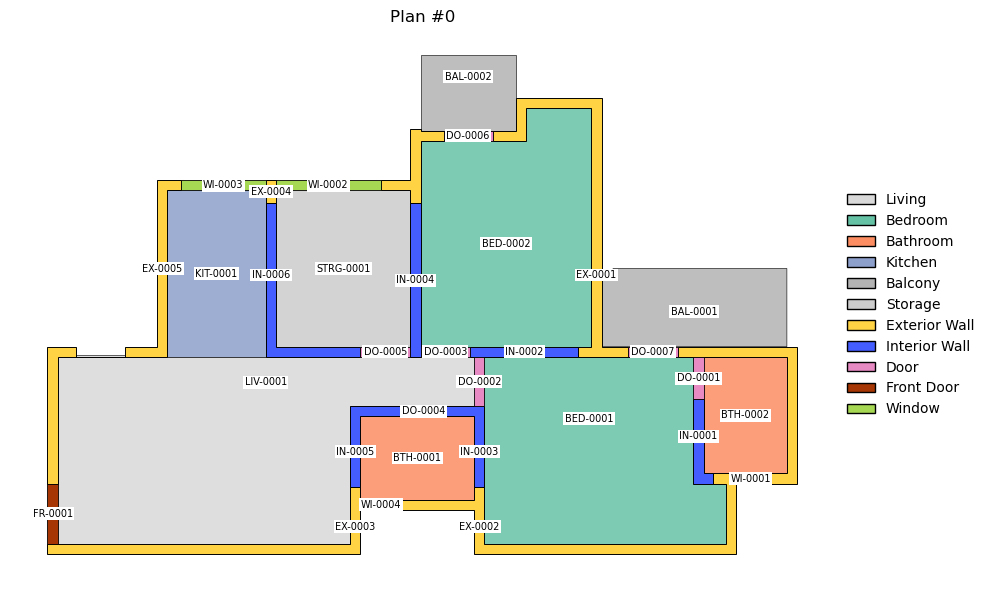

Saved: resplan_plotlabel/plan_00000_ids.png


In [ ]:
# 1) make sure an output dir exists
OUT_PLOTLABEL_DIR = "resplan_plotlabel"
os.makedirs(OUT_PLOTLABEL_DIR, exist_ok=True)

# 2) draw from JSON (IDs already relabeled)
ax_or_none = plot_plan_json(json_path, show_ids=True)
fig = ax_or_none.get_figure() if hasattr(ax_or_none, "get_figure") else plt.gcf()

# 4) save and close
out_png = os.path.join(OUT_PLOTLABEL_DIR, f"plan_{idx:05d}_ids.png")
fig.savefig(out_png, dpi=200, bbox_inches="tight")
plt.close(fig)


print("Saved:", out_png)

## Parsing all dataset into JSON (perfect)

In [ ]:
# import pickle
# import json
# import os
# from tqdm import tqdm
# import matplotlib.pyplot as plt

# # Load all plans
# with open(DATA_PKL, "rb") as f:
#     plans = pickle.load(f)

# # Create output directories
# OUT_JSON_DIR = "resplan_json"
# OUT_PNG_DIR = "resplan_png"
# OUT_PLOTLABEL_DIR = "resplan_plotlabel"

# os.makedirs(OUT_JSON_DIR, exist_ok=True)
# os.makedirs(OUT_PNG_DIR, exist_ok=True)
# os.makedirs(OUT_PLOTLABEL_DIR, exist_ok=True)

# print(f"Total plans to process: {len(plans)}")

# # Process all plans
# failed_indices = []

# for idx in tqdm(range(len(plans)), desc="Processing plans"):
#     try:
#         # Normalize and export to JSON
#         plan = R.normalize_keys(plans[idx].copy())
#         json_path = export_one(idx, plan)
        
#         # Move JSON to dedicated directory if needed
#         target_json = os.path.join(OUT_JSON_DIR, f"plan_{idx:05d}.json")
#         if json_path != target_json:
#             os.rename(json_path, target_json)
#             json_path = target_json
        
#         # Generate unlabeled PNG
#         ax = plot_plan_json(json_path, show_ids=False)
#         fig = ax.get_figure() if hasattr(ax, "get_figure") else plt.gcf()
#         out_png = os.path.join(OUT_PNG_DIR, f"plan_{idx:05d}.png")
#         fig.savefig(out_png, dpi=200, bbox_inches="tight")
#         plt.close(fig)
        
#         # Generate labeled PNG with IDs
#         ax = plot_plan_json(json_path, show_ids=True)
#         fig = ax.get_figure() if hasattr(ax, "get_figure") else plt.gcf()
#         out_labeled = os.path.join(OUT_PLOTLABEL_DIR, f"plan_{idx:05d}_ids.png")
#         fig.savefig(out_labeled, dpi=200, bbox_inches="tight")
#         plt.close(fig)
        
#     except Exception as e:
#         failed_indices.append(idx)
#         print(f"\nFailed at index {idx}: {e}")
#         continue

# print(f"\nProcessing complete.")
# print(f"Successful: {len(plans) - len(failed_indices)}")
# print(f"Failed: {len(failed_indices)}")

# if failed_indices:
#     print(f"Failed indices: {failed_indices[:20]}...")  # Show first 20
#     with open("failed_indices.txt", "w") as f:
#         f.write("\n".join(map(str, failed_indices)))